# Specialist Model: Common Resistor Value Detection

This notebook trains the specialist YOLO model to directly classify common resistor values.

The workflow includes:
- Data loading
- Train/validation split
- Model training
- Evaluation
- Prediction and visualization
- Model export and deployment

In [ ]:
# Step 1: Load Dataset

from google.colab import drive
drive.mount('/content/gdrive')
!cp /content/gdrive/MyDrive/S_1.zip /content

In [ ]:
!unzip -q /content/S_1.zip -d /content/custom_data

## Data Preparation

Split dataset into training and validation sets (90/10).


In [ ]:
# Snapshot adapted from external YOLO workflow for dataset splitting

!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

!python /content/train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

In [ ]:
# Install YOLO framework

!pip install ultralytics

## Configuration

Create YOLO data configuration file.

In [ ]:
# Snapshot adapted from external YOLO workflow
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 10
names:
- '10'
- '1000'
- '10000'
- '20000'
- '220'
- '330'
- '4700'
- '6800'
- '8200'
- '9200'


## Model Training

Train YOLO specialist model.

In [ ]:
# After hyperparameter tuning, these settings gave the best results
!yolo detect train \
data=/content/data.yaml \
model=yolo11s.pt \
epochs=40 \
imgsz=640 \
batch=16 \
lr0=0.005

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

## Model Evaluation

Evaluate performance using standard metrics (mAP, Precision, Recall).

In [ ]:
!yolo detect val \
model=/content/runs/detect/train/weights/best.pt \
data=/content/data.yaml

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3630.1±2112.4 MB/s, size: 3250.5 KB)
val: Scanning /content/data/validation/labels.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 11.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.4s/it 9.7s
                   all         59         67      0.954      0.965      0.986       0.82
                    10          7          7      0.961      0.857       0.93      0.546
                  1000          7          7      0.959          1      0.995      0.895
                 10000         10         10      0.971          1      0.995      0.906
                 20000         12         12      0.976          1      0.995      0.954
                   220          6          6 

## Prediction

Run inference on validation images.

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source=/content/custom_data/validation/images \
save=True

## Visualization

Display prediction results for qualitative inspection.

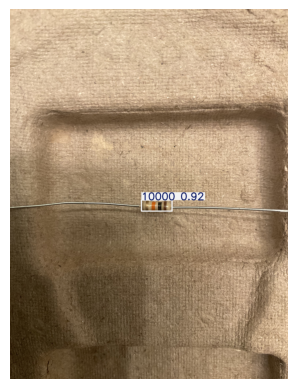

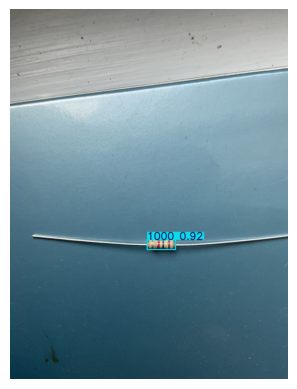

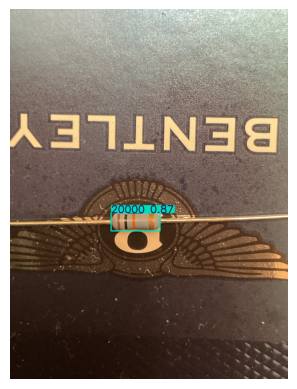

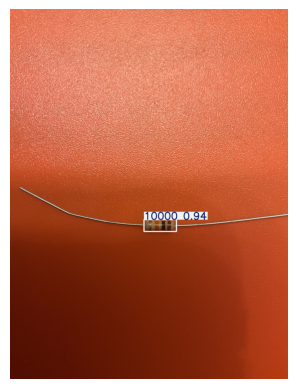

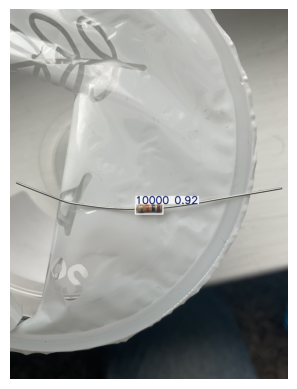

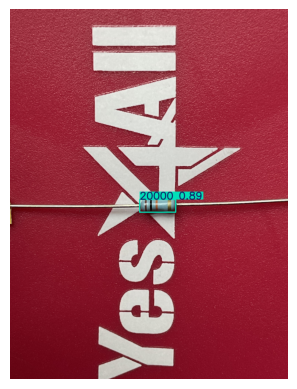

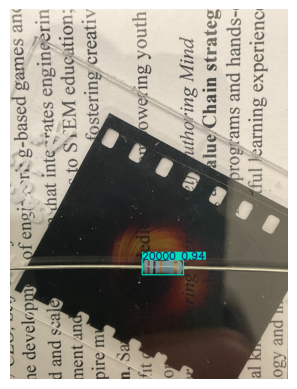

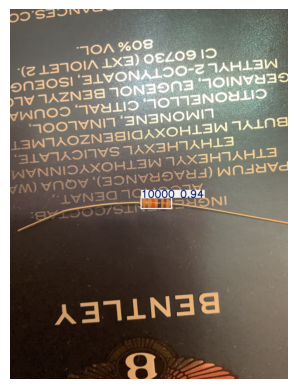

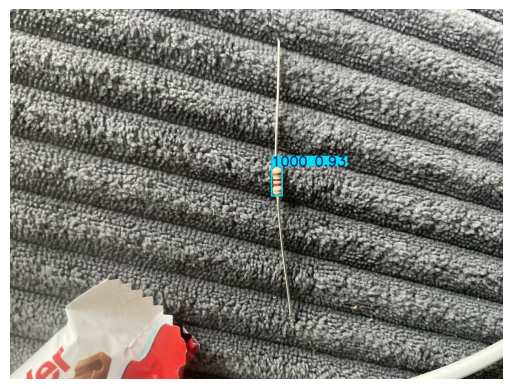

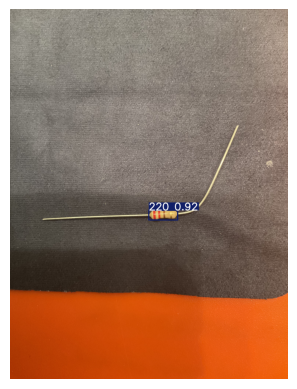

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_dir = "/content/runs/detect/predict/"
images = os.listdir(image_dir)[:10]

for img_file in images:
    img_path = os.path.join(image_dir, img_file)
    img = mpimg.imread(img_path)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

## Model Export

Save trained model for reuse and deployment.

In [ ]:
# Snapshot adapted from external YOLO workflow
!mkdir -p /content/my_SP_1_Model
!cp /content/runs/detect/train/weights/best.pt /content/my_SP_1_Model/my_SP_1_Model.pt
!cp -r /content/runs/detect/train /content/my_SP_1_Model
%cd /content/my_SP_1_Model
!zip /content/my_SP_1_Model.zip my_SP_1_Model.pt
!zip -r /content/my_SP_1_Model.zip train
%cd /content

In [ ]:
from google.colab import files

files.download('/content/my_SP_1_Model.zip')

## Deployment Test

This section tests the saved Specialist model on a new resistor image.

The trained model is loaded from Google Drive so the deployment test can be repeated even after the Colab session resets. After loading the model, a new image is uploaded, passed through the YOLO model, and displayed with the predicted bounding box and resistor value.

In [ ]:
from google.colab import drive
from ultralytics import YOLO
import matplotlib.pyplot as plt
from google.colab import files
import os

drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/my_SP_1_Model.zip -d /content/temp_model/
model_path = '/content/temp_model/my_SP_1_Model.pt'
if os.path.exists(model_path):
    model = YOLO(model_path)
    print("🚀 Model loaded and ready!")
else:
    print("❌ Model file not found. Check if the name inside the zip matches.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Model loaded and ready!


Saving IMG_1847.jpeg to IMG_1847.jpeg

image 1/1 /content/IMG_1847.jpeg: 640x480 1 6800, 57.6ms
Speed: 3.3ms preprocess, 57.6ms inference, 16.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


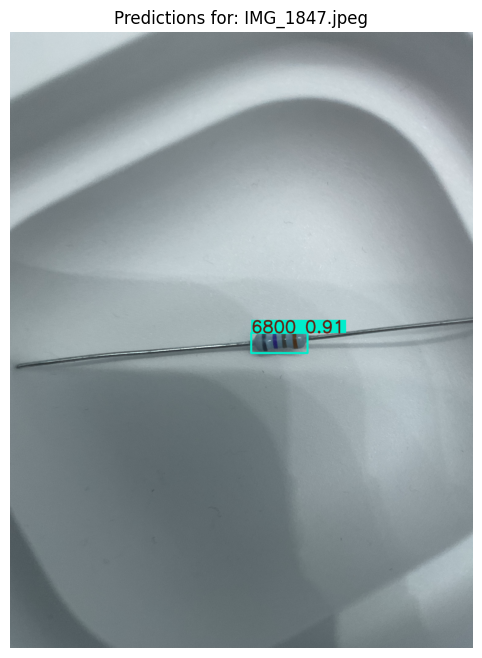

In [ ]:
uploaded = files.upload()
if uploaded:
    image_path = list(uploaded.keys())[0]
    results = model.predict(source=image_path, save=True, conf=0.25)

    res_plotted = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.title(f"Predictions for: {image_path}")
    plt.show()

## Code Attribution

Portions of this notebook were adapted from external YOLO training workflows to support standard dataset preparation and model configuration tasks.

Specifically, the train/validation split script was adapted from the EdjeElectronics YOLO training workflow. The YAML configuration structure was also adapted from common Ultralytics YOLO dataset formatting practices.

These sections were used only for setup and workflow organization. The project-specific work, including dataset creation, resistor labeling logic, model purpose, training decisions, evaluation, and interpretation, was completed for this resistor recognition project.